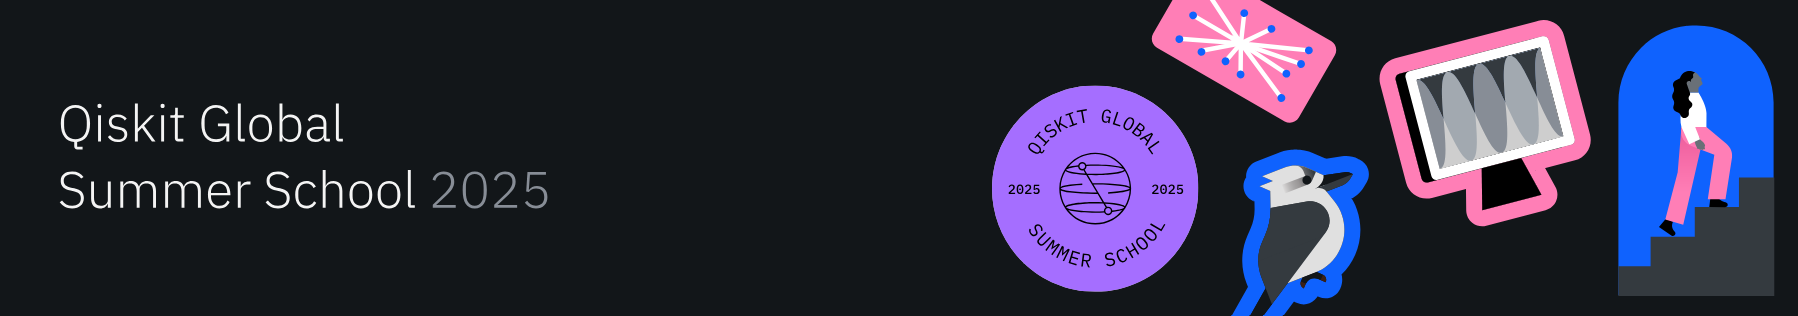

# Lab 1: 自宅で有名な実験を再現しよう！

# 0. セットアップ：ツールの収集

どんな良い実験にも準備が必要です。この場合の準備とは、使用するPythonライブラリ、特に量子コンピューティングのツールキットであるQiskitを用意することです。Lab 0 を完了していれば、すでに準備は整っているはずです。まだ完了していない場合は、以下のセルのコメントアウトを外して実行することで、Qiskit v2.x とサマースクールで必要なライブラリがインストールされる grader を導入できます。

In [ ]:
# %pip install "qc-grader[qiskit,jupyter] @ git+https://github.com/qiskit-community/Quantum-Challenge-Grader.git"

In [1]:
import qiskit
import qc_grader
print(f"Qiskit version: {qiskit.__version__}")
print(f"Grader version: {qc_grader.__version__}")

Qiskit version: 2.1.1
Grader version: 0.22.12


Qiskitバージョン `> = 2.0.0`とGrader`> = 0.22.9`が必要です。低いバージョンが表示されている場合は、カーネルを再起動してグレーダーを再度インストールする必要があります。
また、Lab 0に従ってすべてをセットアップし、以下のセルでテストしてください。

In [3]:
# アカウントが正しく保存されていることを確認してください
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService(name="qgss-2025")
service.saved_accounts()

{'qgss-2025': {'channel': 'ibm_quantum_platform',
  'url': 'https://cloud.ibm.com',
  'token': 'cxkGGSsPsLFOp4IzswIFk-JEeUsKns0muIGxsAsRwSHg',
  'instance': 'crn:v1:bluemix:public:quantum-computing:us-east:a/3efbef98d82f4ca4b5cdd753e9f179e2:48f95bc0-755a-4f6b-9e43-664f3d8415e3::',
  'verify': True,
  'private_endpoint': False}}

## インポート

以下のセルは、これらの必要なライブラリをインポートし、Qiskit バージョンを表示します。

In [4]:
# Essential libraries
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from PIL import Image
import io

from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.visualization import plot_histogram, plot_distribution
from qiskit_ibm_runtime import Options, Session, SamplerV2 as Sampler
from qiskit.result import marginal_distribution

from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_aer import AerSimulator

from qc_grader.challenges.qgss_2025 import (
    grade_lab1_ex1_1, 
    grade_lab1_ex1_2, 
    grade_lab1_ex1_3, 
    grade_lab1_ex1_4, 
    grade_lab1_ex2, 
    grade_lab1_ex3,
    grade_lab1_ex4,
    grade_lab1_ex5,
    grade_lab1_ex6
)

---
# 目次

1. 重ね合わせ、干渉、測定
    1. 二重スリット実験 - 重ね合わせ、干渉
    2. シュレディンガーの猫と二重スリットの再訪
2. エンタングルメント
    1. アリス、ボブ、そして無敵のゲームの奇妙なケース - CHSHゲーム
    2. 量子テレポーテーション - 不気味な行動で秘密を送る
        1. シミュレータ上でのテレポーテーション
3. （ボーナスチャレンジ）実際の量子ハードウェア上でのテレポート
---


2025年、国際量子年の幕開けにようこそ！これはQGSS（Quantum Grad School Summer）の最初のラボです。この最初のラボでは、量子の世界で最も重要な4つの概念——重ね合わせ、干渉、測定、そしてエンタングルメント（量子もつれ）——を、Qiskit を使った実験を通して学んでいきます。

# 第1章： 重ね合わせ、干渉、測定

このクールな旅のスタートにふさわしく、まずは重ね合わせ、干渉、量子測定を、「二重スリット実験」という有名な実験を通して探究していきましょう。

**重ね合わせ**とは、例えば電子や光子のような量子粒子が同時に複数の状態に存在できるという性質です。たとえば、1つの場所にいると同時に別の場所にもいることができたり、2つのエネルギー状態を同時に持ったりするのです。コインを投げたときに、表と裏の両方が同時に出ているようなもの... ただし、あなたが「見る（測定する）」までは！

**干渉**は、そうした量子的な可能性が「波」のように重なり合ったときに起こる現象です。波同士が同位相であれば互いに強め合い（建設的干渉）、逆位相であれば打ち消し合って弱め合ったり消えたりします（破壊的干渉）。これは二重スリット実験における重要な効果のひとつです。

この概念を示す最も有名な実験が、**二重スリット実験**です。1801年にトーマス・ヤングが最初に行い、その後、電子などの単一粒子を使っても繰り返されました。粒子がどちらのスリットを通ったかを「誰も見ていない」とき、美しい干渉パターンが現れます。まるで波が重なり合うように。しかし、どちらのスリットを通ったかを**測定**した瞬間、そのパターンは消えてしまいます。まるで、粒子が「見られている」ことを知っているかのようです！

この奇妙な概念をさらに発展させたのが、1935年にエルヴィン・シュレーディンガーが提唱した**シュレーディンガーの猫**という思考実験です。この実験では、猫が「生きている」と「死んでいる」の両方の状態にあるとされます——誰かが箱を開けて中を確認するまでは。量子力学における測定は、「観測する」だけではなく、「現実そのものを形作る」力を持っているのです。

量子の不思議に、あなた自身の手で触れてみませんか？ Qiskit を使えば、二重スリット実験を測定あり・なしの両方でシミュレーションできます。重ね合わせと干渉によってどのように美しいパターンが生まれるのか、そして測定が量子系にどのように影響を与えるのかを、自分の手で実際に体験することができます。量子の神秘を探る、楽しくて目からウロコの旅が始まります！

## スリットを通る： 量子の奇妙さの始まり

<p style="text-align:center;">
        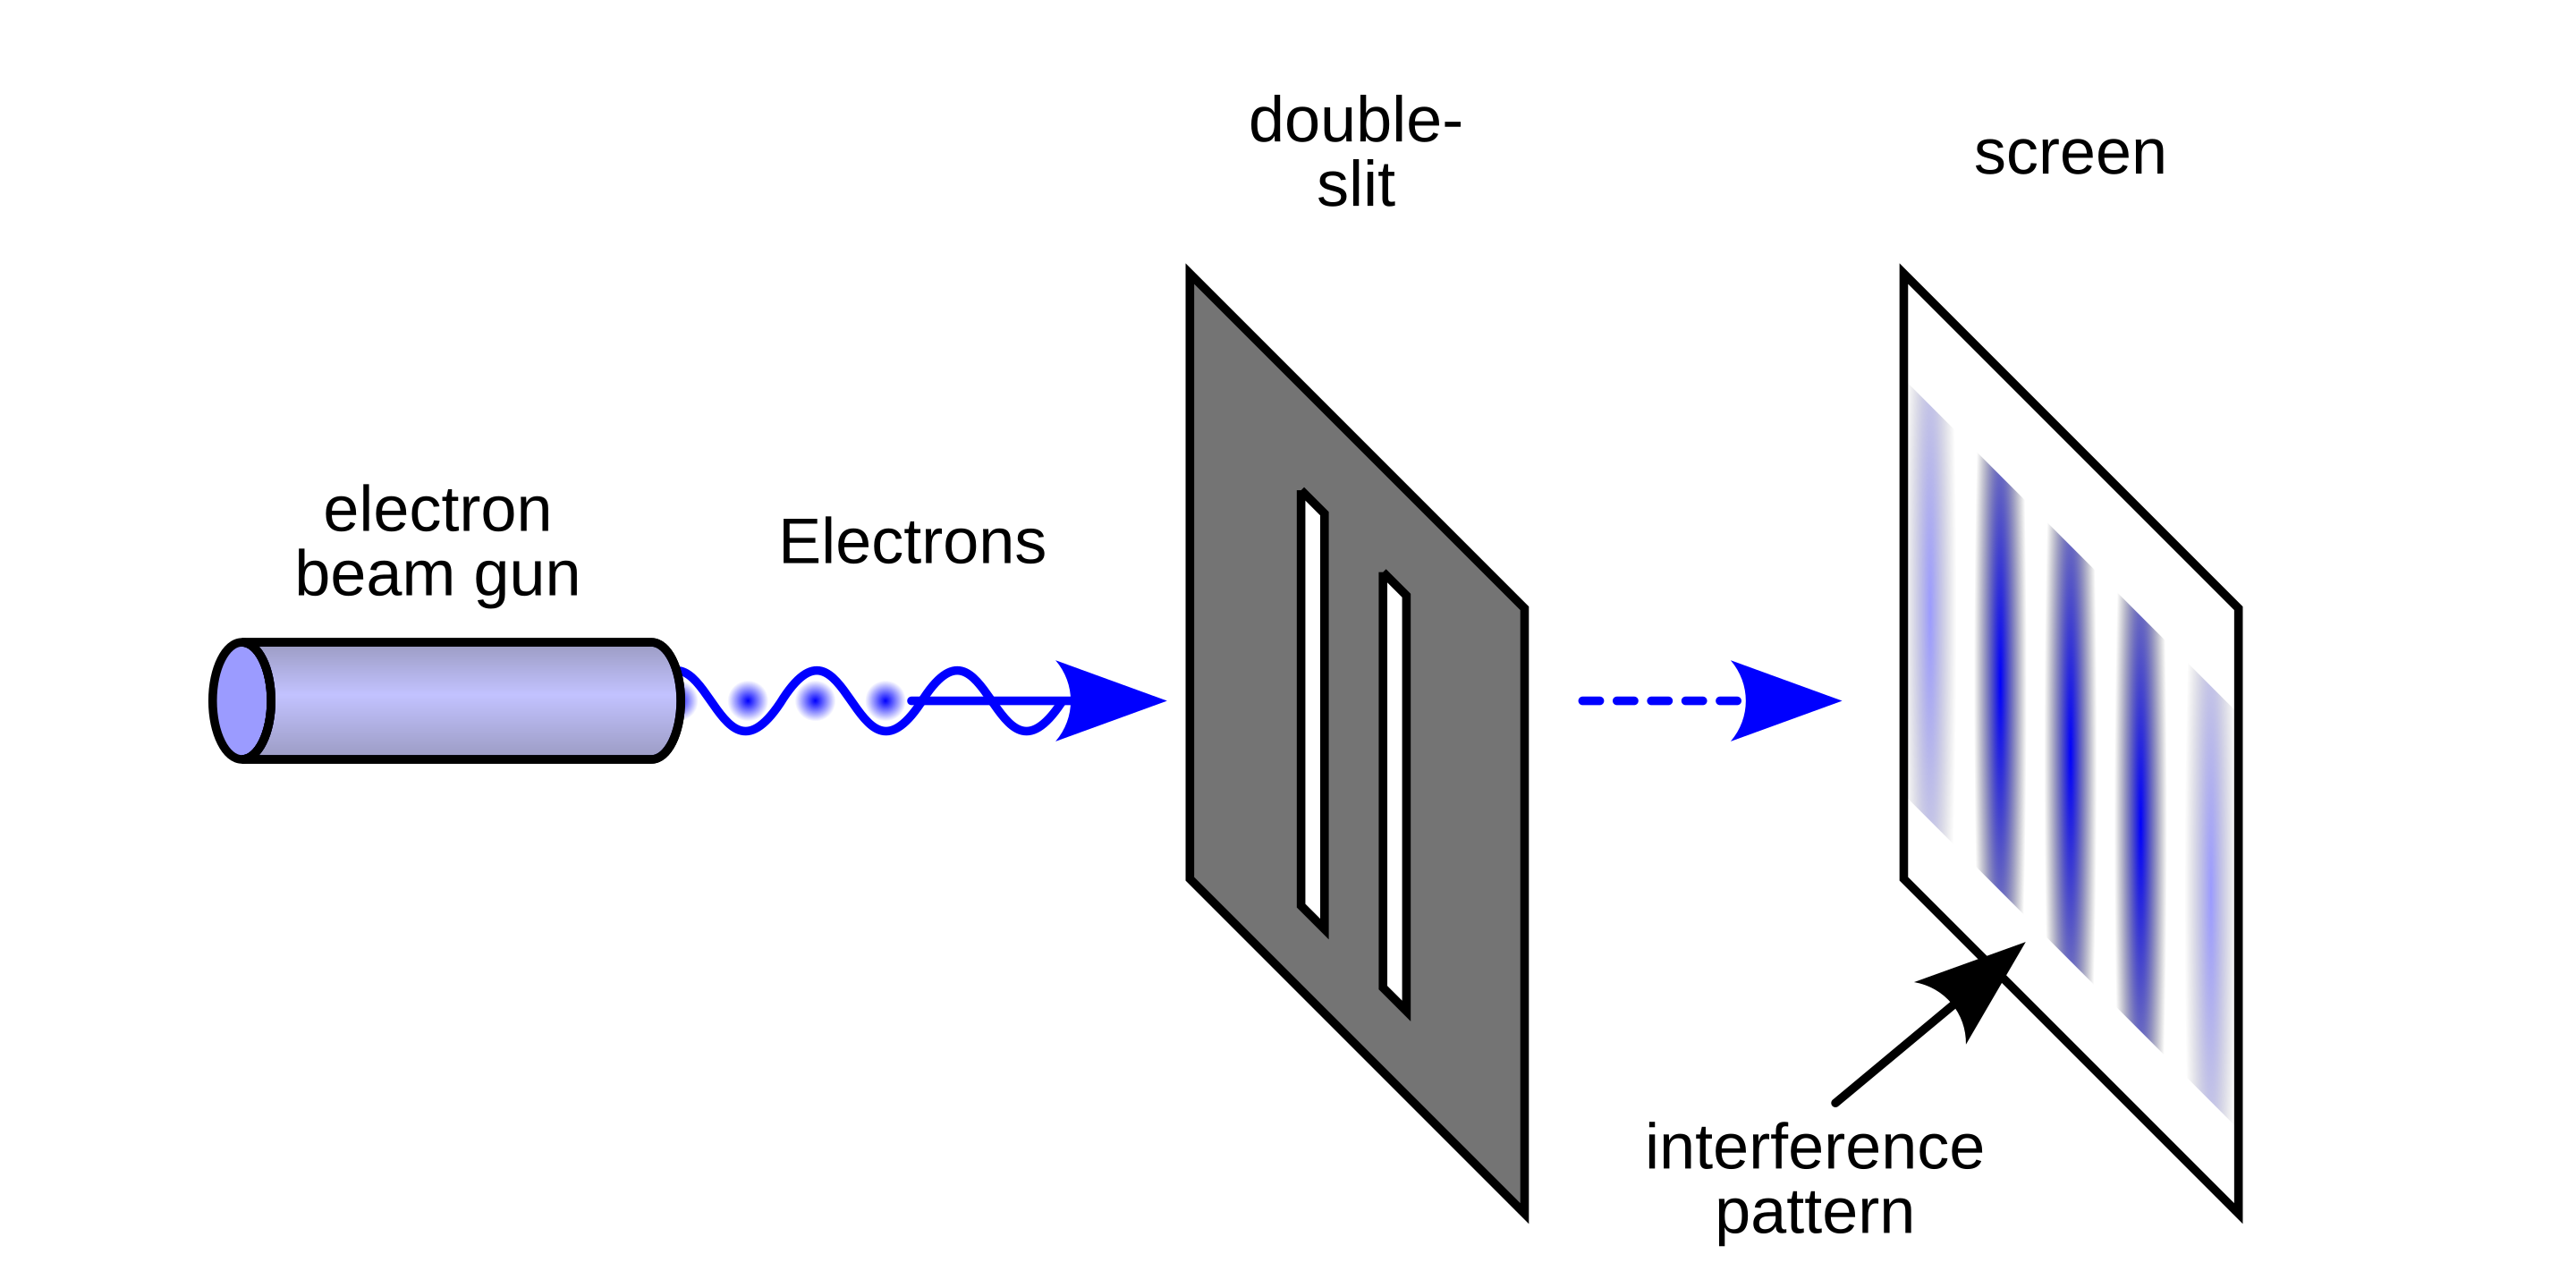

</p>
<p style="text-align:center;">
    wikipedia の画像
</p>

1803年、トーマス・ヤングは論文「Experiments and calculations relative to physical optics（物理光学に関する実験と計算）」の中で、次のように自身の実験について述べています：

> 私は窓の雨戸に小さな穴を開け、それを厚紙で覆い、細い針で穴をあけました。観察をより便利にするために、窓の外側に小さな鏡を置き、太陽光をほぼ水平な方向に反射させて反対側の壁に当て、広がる光の円錐が、厚紙で作ったいくつかの小さなスクリーンを置いたテーブルの上を通るようにしました。[1](https://royalsocietypublishing.org/doi/pdf/10.1098/rstl.1804.0001)

この実験により、ヤングは光による美しい縞模様（干渉縞）を観察し、これは2つの光線の経路の長さの違いに起因すると説明しました。その後、ジョージ・パジェット・トムソンは電子を使った類似の実験（電子回折実験）を行い、電子のような粒子でも波のような振る舞いを示すことを実証しました（1927年の論文にて）。[2](https://royalsocietypublishing.org/doi/10.1098/rspa.1927.0130) 

さらに1965年、リチャード・ファインマンは「ファインマン物理学講義 第3巻 第1章」においてこの二重スリット実験を紹介し、これが量子力学における重ね合わせと干渉に由来する現象であると説明しました。

現代では、こうした魅力的な量子現象を複雑な実験装置なしに、Qiskit を使って再現することができます。ここからは、量子回路上でどのように「重ね合わせ」と「干渉」が実現されるかを見ていきましょう。

まず最初のステップは、「物理的な二重スリット実験」を量子回路に対応づけることです。
これが、あなたの最初の演習課題です。

<div class="alert alert-block alert-success">
<b>Exercise 1：二重スリット実験のための量子回路を構築する</b>

- Exercise 1-1：スリットを作る

**目標：** 2つのスリットを通過する粒子（量子ビット）をモデル化する量子回路を作成し、$|0\rangle$ （下部スリット）および　$|1\rangle$ （上部スリット）状態にあるという重ね合わせを実現します。

上部スリットを量子ビットが $|1\rangle$ の状態で、下部スリットは $|0\rangle$ の状態として定義しましょう。最初は $|0\rangle$ で量子ビットが　$|0\rangle$　と　$|1\rangle$　の重ね合わせでスリットを通過する量子回路を[アダマールゲート](https://quantum.cloud.ibm.com/docs/api/qiskit/qiskit.circuit.library.HGate)を用いて実装します。回路を描いてください。

**ヒント**：特定の名前を `QuantumRegister` （例 `name='q'` ）や `classicalregister`（例: `name='c_screen'`）に割り当てることは、測定データを解釈するときに明確にするために有益です。

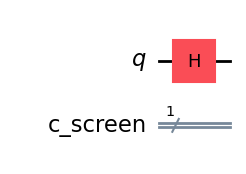

In [14]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister

qr = QuantumRegister(1, name='q')
cr = ClassicalRegister(1, name='c_screen')

double_slit = QuantumCircuit(qr, cr)
# 以下にコードを記述してください
double_slit.h(0)


# コードはここまでです
double_slit.draw('mpl')

In [15]:
# Submit your answer using following code
grade_lab1_ex1_1(double_slit)

Submitting your answer. Please wait...
Congratulations! 🎉 Your answer is correct.


<div class="alert alert-block alert-success">
<b>Exercise　1: 二重スリット実験のための量子回路を構築する</b>

- 演習1-2: スクリーンの作成

**目標**: 前の回路を拡張して、干渉が発生するスクリーンをモデル化します。具体的には、位相差が現れない画面の中心を実装して量子ビットを測定します。

ではゲートを追加して2つの重ね合わせの量子状態が干渉パターンを作成するスクリーンを実装します。まず、スクリーンの中心を実装しましょう。ここでは2つのビームが位相差なし（$|0\rangle$ 状態）で組み合わされます。次に、`qr` から量子ビットを測定し、結果を `c_screen` に保存します。

**ヒント**：アダマールゲートを再度使用できます。
</div>


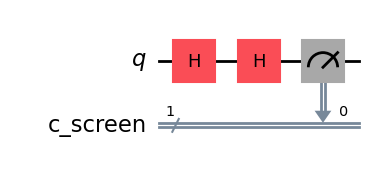

In [16]:
# 以下にコードを記述してください
double_slit.h(0)
double_slit.measure(qr, cr)

# コードはここまでです
double_slit.draw('mpl')

In [17]:
# Submit your answer using following code
grade_lab1_ex1_2(double_slit)

Submitting your answer. Please wait...
Congratulations! 🎉 Your answer is correct.


実行結果を確認しましょう。スクリーンが $|0\rangle$ の状態で量子ビットを検出すると仮定すると、次のコードは理想的なシミュレーター上で回路を実行します。 確率 1 は 100％ を意味します。

<div class="alert alert-block alert-info">
<b>SamplerV2を使用した測定結果の取得に関する注意</b> 

Qiskit で *SamplerV2* を使用する場合、測定カウントを取得する方法は、古典レジスタと測定のセットアップ方法によって異なります。

1. *QuantumCircuit*　の古典レジスタに名前を付ける:
    たとえば、*cr = ClassicalRegister(1, name='my_results')* および *qc = QuantumCircuit(qr, cr)*、そして測定 *qc.measure(qr[0], cr[0])* のように回路を名前付き古典レジスタを使って定義する場合、その名前を使用してカウントにアクセスします。

    
    ```python
    # result = job.result()
    # counts = result[0].data.my_results.get_counts()
    ```
    
    double_slit 回路では、*cr = ClassicalRegister(1, name='c_screen')* を使用したため、*result[0].data.c_screen.get_counts()* を使用します。

3. measure_all():
   *qc.measure_all()* を使用すると、Qiskit は古典ビットを自動的に追加し、出力データフィールドに`meas` と名前を付けます。

    
    ```python
    # qc.measure_all()
    # ...
    # counts = result[0].data.meas.get_counts()
    ```

5. 暗黙的な古典ビット（ *QuantumCircuit* 内で命名されていないレジスタ）:
   *qc = QuantumCircuit(1, 1)* (1 量子ビット, 1 古典ビット) や *qc = QuantumCircuit(QuantumRegister(1), ClassicalRegister(1))* などのようにコンストラクタで古典レジスタを命名せずに回路を作成して *qc.measure(0, 0)* を使用した場合、*SamplerV2* は結果をデフォルトの名前（大抵は *c* であったり *c0* のように古典ビットのインデックス）に保存する可能性があります。
   *qc = QuantumCircuit(1,1)* および *qc.measure(0,0)* の場合、次のようにして出力にアクセスできます。

    ```python 
     # counts = result[0].data.c0.get_counts() # If single bit named c0, the indice can vary. You can see the actial indices when you plot your circuit.
    ```
</div>


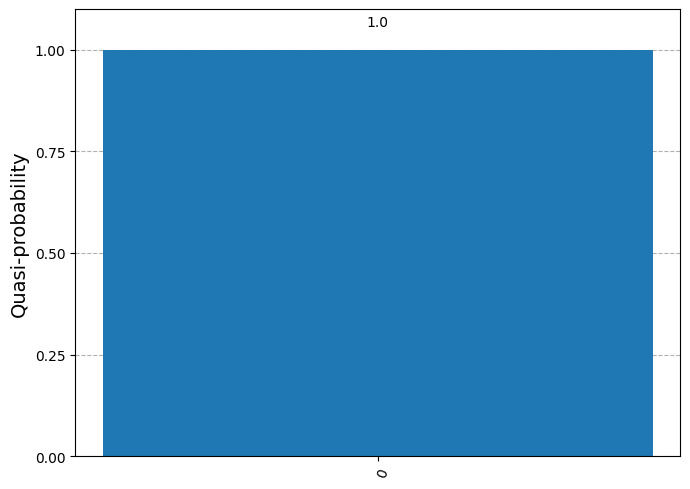

In [18]:
# use simulator
backend = AerSimulator()

# make quantum circuit compatible to the backend
pm = generate_preset_pass_manager(backend = backend, optimization_level=3)
qc_isa = pm.run(double_slit)

# run and get counts
sampler = Sampler(mode=backend)
counts = sampler.run([qc_isa], shots = 1000).result()[0].data.c_screen.get_counts()

plot_distribution(counts)

<div class="alert alert-block alert-success">
<b>Exercise1: 二重スリット実験のための量子回路を構築する</b>

- Exercise 1-3：差を作る

**目標**: 二重スリット回路を変更して、2つのパス（スリット）間に位相差を導入し、スクリーンの測定結果に対する影響を観察します。

ではスクリーンの別の部分を実装しましょう。 2つのビーム間のパスの差は、$|0\rangle$ と $|1\rangle$ の位相差として実装されます。 重ね合わせの量子状態の $|1\rangle$ の状態にのみ $\pi/2$ の位相をかけて測定結果を観測してください。（ヒント：$|1\rangle$ 状態に位相をかけるゲートを使用します。[Pゲート](https://quantum.cloud.ibm.com/docs/api/qiskit/qiskit.circuit.library.PhaseGate)と[Sゲート](https://quantum.cloud.ibm.com/docs//api/qiskit/qiskit.circuit.library.SGate)が代表的な例です。）

</div>


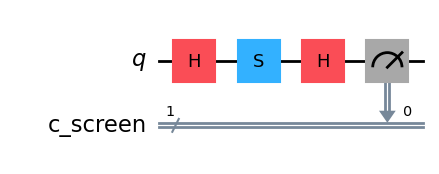

In [19]:
qr = QuantumRegister(1, name='q')
cr = ClassicalRegister(1, name='c_screen')

double_slit_with_difference = QuantumCircuit(qr, cr)
double_slit_with_difference.h(0)
# 以下にコードを記述してください
double_slit_with_difference.s(0)

# コードはここまでです
double_slit_with_difference.h(0)
double_slit_with_difference.measure(qr, cr)
double_slit_with_difference.draw('mpl')

In [20]:
# 次のコードを実行して、課題を提出してください
grade_lab1_ex1_3(double_slit_with_difference)

Submitting your answer. Please wait...
Congratulations! 🎉 Your answer is correct.


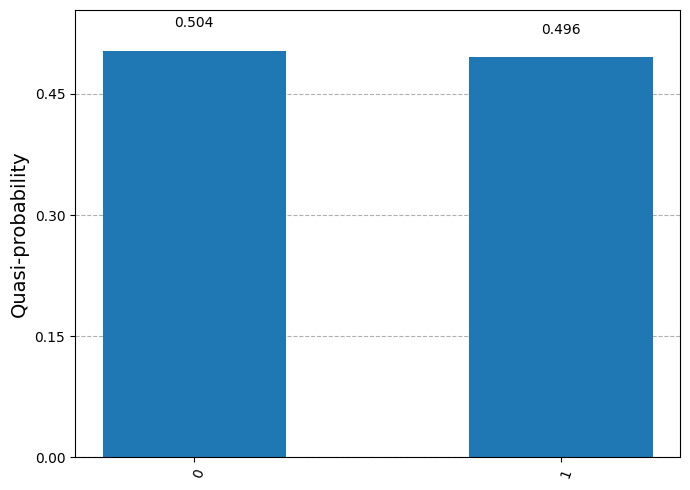

In [21]:
qc_isa = pm.run(double_slit_with_difference)

# 実行してカウントを取得
sampler = Sampler(mode=backend)
counts = sampler.run([qc_isa], shots=10000).result()[0].data.c_screen.get_counts()
plot_distribution(counts)

ご覧のとおり、$|0\rangle$ を測定する確率は約 0.5（50％）に減少し、画面上のこの時点での明るさの減少を示しています。
 

さらに進む前に、このプロセスの単純な数学を、重ね合わせ、干渉、および量子状態の測定の確率の側面で行います。この概念に既に馴染みがある場合は、この部分をスキップできます。

<details>
<summary> <h3>重ね合わせ、干渉、測定確率</h3> </summary>


二重スリット実験の量子回路実装では、連続するアダマール（H）ゲートと位相ゲート（P）を使用しました。各ステップでの量子状態の数学的表現に分解し、重ね合わせ、干渉、および測定確率を分析しましょう。

**1.初期化:**

スリットの前の光源から照射される電子を表す $|0\rangle$ 状態で初期化された単一の量子ビットから始めます。

$$ |\psi_0\rangle = |0\rangle = \begin{pmatrix} 1 \\ 0 \end{pmatrix} $$

ここでは、$ |\psi_1\rangle$ が上部スリットを通過できる別の量子状態であると仮定します。これは次のとおりです。

$$ |\psi_1\rangle = |1\rangle = \begin{pmatrix} 0 \\ 1 \end{pmatrix} $$

**2.重ね合わせ（最初のアダマールゲート）:**

最初のアダマールゲート（H）が量子ビットに適用します。この操作は、$|0\rangle$ と $|1\rangle$ の状態の重ね合わせを作成し、両方のスリットを同時に通過する電子を表します。

$$ H = \frac{1}{\sqrt{2}} \begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix} $$

H を $|\psi_0\rangle$ に適用します。

$$ |\psi_1\rangle = H |\psi_0\rangle = \frac{1}{\sqrt{2}} \begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix} \begin{pmatrix} 1 \\ 0 \end{pmatrix} = \frac{1}{\sqrt{2}} \begin{pmatrix} 1 \\ 1 \end{pmatrix} = \frac{1}{\sqrt{2}} (|0\rangle + |1\rangle) $$

この状態 $|\psi_1\rangle$ は、量子ビットが $|\psi_0\rangle$ 状態（一方のスリットを表す）と $|\psi_1\rangle$ 状態（他方のスリットを表す）の等しい重ね合わせにあることを示しています。

**3.位相シフト（Pゲート）：**

位相ゲート（P）は、 $|0\rangle$ と $|1\rangle$ コンポーネントの間に相対位相 $\phi$ を導入します。この位相差は、物理実験では2つのスリットを通過する電子波が辿った経路差に対応します。 P ゲートは次のように定義されています。

$$ P(\phi) = \begin{pmatrix} 1 & 0 \\ 0 & e^{i\phi} \end{pmatrix} $$

$P(\phi)$ を $|\psi_1\rangle$ に適用します。

$$ |\psi_2\rangle = P(\phi) |\psi_1\rangle = \begin{pmatrix} 1 & 0 \\ 0 & e^{i\phi} \end{pmatrix} \frac{1}{\sqrt{2}} \begin{pmatrix} 1 \\ 1 \end{pmatrix} = \frac{1}{\sqrt{2}} \begin{pmatrix} 1 \\ e^{i\phi} \end{pmatrix} = \frac{1}{\sqrt{2}} (|0\rangle + e^{i\phi}|1\rangle) $$

状態 $|\psi_2\rangle$ には、干渉に重要な相対位相情報が含まれるようになりました。

**4.干渉（2つ目のアダマールゲート）：**

2番目のアダマールゲートが適用され、重ね合わせの状態を取り戻し、干渉することができます。

$$ |\psi_3\rangle = H |\psi_2\rangle = \frac{1}{\sqrt{2}} \begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix} \frac{1}{\sqrt{2}} \begin{pmatrix} 1 \\ e^{i\phi} \end{pmatrix} = \frac{1}{2} \begin{pmatrix} 1 + e^{i\phi} \\ 1 - e^{i\phi} \end{pmatrix} $$

$e^{i\phi} = \cos(\phi) + i\sin(\phi)$ を展開すると:

$$ |\psi_3\rangle = \frac{1}{2} \begin{pmatrix} 1 + \cos(\phi) + i\sin(\phi) \\ 1 - (\cos(\phi) + i\sin(\phi)) \end{pmatrix} = \frac{1}{2} \begin{pmatrix} (1 + \cos(\phi)) + i\sin(\phi) \\ (1 - \cos(\phi)) - i\sin(\phi) \end{pmatrix} $$

測定前のこの最終状態は、干渉効果を具現化しています。ここで、 $|0\rangle$ または $|1\rangle$ を測定する確率は、位相差 $\phi$ に依存します。

**5.測定確率：**

量子ビットが $|0\rangle$ の状態（スクリーンの一部に対応）で測定される確率は、$|\psi_3\rangle$　の $|0\rangle$ の振幅の2乗の大きさによって与えられます。

$$ P(|0\rangle) = \left| \frac{1}{2} (1 + e^{i\phi}) \right|^2 = \left| \frac{1}{2} (1 + \cos(\phi) + i\sin(\phi)) \right|^2 $$

$$ P(|0\rangle) = \frac{1}{4} [(1 + \cos(\phi))^2 + (\sin(\phi))^2] = \frac{1}{4} [1 + 2\cos(\phi) + \cos^2(\phi) + \sin^2(\phi)] $$

$\cos^2(\phi) + \sin^2(\phi) = 1$ を使用して:

$$ P(|0\rangle) = \frac{1}{4} [1 + 2\cos(\phi) + 1] = \frac{1}{4} [2 + 2\cos(\phi)] = \frac{1}{2} (1 + \cos(\phi)) $$

$\phi = \pi/2$、$P(|0\rangle) = \frac{1}{2} (1 + \cos(\pi/2)) = 0.5$ の場合、既に確認した結果となります。

</details>


$\phi$ を変えて干渉縞を生成して Exercise 1 を締めくくりましょう。

<div class="alert alert-block alert-success">
<b>Exercise 1: 二重スリット実験のための量子回路を構築する</b>

- Exercise 1-4：美しい干渉縞

**目標：** 位相差 $\phi$ を変更できるパラメータ化された量子回路を作成してください。これにより完全な干渉縞をシミュレートして可視化することができます。

Qiskit では、[量子回路で `Parameters` を使用](https://quantum.cloud.ibm.com/docs/api/qiskit/qiskit.circuit.Parameter)することができます。これを `Sampler` で使用して干渉縞を観測します。

パラメータ $\phi$ を使用して、二重スリット実験のパラメータ化された量子回路を定義してください。一般的な構造は、測定前にHゲート、$p(\phi)$、次に別のHゲートです。 `q` を測定し、`c_screen` に保存してください。
</div>


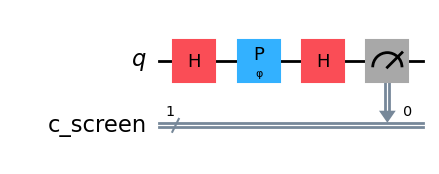

In [24]:
φ = Parameter('φ')

qr = QuantumRegister(1, name='q')
cr = ClassicalRegister(1, name='c_screen')

double_slit_fringe = QuantumCircuit(qr, cr)

# 以下にコードを記述してください
double_slit_fringe.h(0)
double_slit_fringe.p(φ, 0)
double_slit_fringe.h(0)
double_slit_fringe.measure(qr, cr)

# コードはここまでです
double_slit_fringe.draw('mpl')

In [25]:
# 次のコードを実行して、課題を提出してください
grade_lab1_ex1_4(double_slit_fringe)

Submitting your answer. Please wait...
Congratulations! 🎉 Your answer is correct.


素晴らしい！次に、このパラメーター化された回路を使用して、matplotlib のヒートマップを使用して干渉縞をプロットしましょう。以下のコードは 100 個の位相値を生成し、`Sampler` を介して回路（それぞれ 1000 ショット）を実行、$|\psi_0\rangle$ を測定する確率を保存、ヒートマップをプロットします。

<div class="alert alert-block alert-warning">
<b>リソース制約</b>

以下のコードを実際のバックエンドで実行する場合、パラメータまたはショットの数を増やすと、予想よりも多くの QPU 時間が消費されます。現在の構成（100 個のパラメータ回路 + 1000 ショット）では、QPU 時間の消費は1分未満のため、可能であればこの設定を維持してください。

</div>


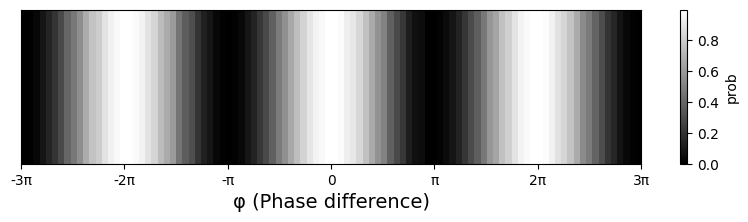

In [27]:
φ_lst = np.linspace(-3*np.pi, 3*np.pi, 100)
qc_isa = pm.run(double_slit_fringe)

φ_hit = []
dist = sampler.run([(qc_isa, φ_lst)], shots=1000).result()[0].data.c_screen

for i  in range(len(φ_lst)):
    result = dist[i].get_counts()
    if '0' in result:
        φ_hit.append(result['0']/1000)
    else:
        φ_hit.append(0)

#plot heat map
φ_hit_2d = np.array(φ_hit).reshape(1, -1)

plt.figure(figsize=(10, 2))
plt.imshow(φ_hit_2d, cmap='gray', aspect='auto', extent=[-3*np.pi, 3*np.pi, 0, 0.1])

plt.xlabel('φ (Phase difference)', fontsize=14)
plt.colorbar(label='prob')
plt.xticks(ticks=[-3*np.pi, -2*np.pi, -np.pi, 0, np.pi, 2*np.pi, 3*np.pi],
           labels=['-3π', '-2π', '-π', '0', 'π', '2π', '3π'])
plt.yticks([])  
plt.show()

素晴らしい！量子ビットを使用して、二重スリット実験の干渉縞を再現しました。では次に、シュレーディンガーの猫を使用した量子測定を探求し、測定が二重スリットの結果にどのように影響するかを確認していきましょう。


## シュレーディンガーの猫： 量子の重ね合わせと観測行為の探求

このエルヴィン・シュレーディンガーによる思考実験（1935年、「[Die gegenwärtige Situation in der Quantenmechanik](https://link.springer.com/article/10.1007/BF01491891)」）は、量子重ね合わせと、測定がいかにして可能性を一つの結果へと「収束」させるかを示しています。箱の中に封じられた猫は、放射性原子と一緒に入れられます。もし原子が「崩壊した／していない」という重ね合わせ状態にあるなら、その原子と絡み合った猫もまた、「生きている／死んでいる」という重ね合わせ状態にあることになります。そして観測が行われるまで、猫の状態は確定しません。

ここでは、回転ゲートを使ってこの状況を模擬します。猫は $|1\rangle$ の状態を嫌っているとしましょう。箱を「開ける」（つまり量子ビットを測定する）ことで、猫が「ご機嫌」か「ご立腹」かが分かります。気をつけて！怒った量子猫に引っかかれるかもしれません。

<div class="alert alert-block alert-success">
<b>Exercise 2: 猫はご機嫌ですか、ご立腹ですか？</b>

**目標：** $R_X(\theta)$ ゲートを使用して重ね合わせ状態の量子ビットを準備する量子回路を作成してください。そして1回の測定をシミュレートして、「猫」（量子状態で表現されています）が「ご機嫌」($|0\rangle$) であるか 「ご立腹」($|1\rangle$) であるかを判定してください。

[回転 X ゲート](https://quantum.cloud.ibm.com/docs/api/qiskit/qiskit.circuit.library.RXGate)を使用して、以下のPythonコードを完成させてください。次に、猫がご機嫌（$|0\rangle$）またはご立腹（$|1\rangle$）かを確認します。 $\theta$ はスライダーから与えられます。

</div>


In [30]:
def schrodingers_cat_experiment_theta(theta):
    
    qc = QuantumCircuit(1)

    # 以下にコードを記述してください
    qc.rx(theta, 0)
    
    
    # コードはここまでです

    qc.measure_all()
    
    backend = AerSimulator()
    pm = generate_preset_pass_manager( backend = backend, optimization_level=3)
    qc_isa = pm.run(qc)

    # Circuit compile and run, shot = 1 
    sampler = Sampler(mode=backend)
    counts = sampler.run([qc_isa], shots = 1).result()[0].data.meas.get_counts()

    measured_state = list(counts.keys())[0] if counts else '0'  # bring measured result

    if measured_state == '0':
        cat_happy = True
    else:
        cat_happy = False

    return cat_happy, qc

In [31]:
# 次のコードを実行して、課題を提出してください
grade_lab1_ex2(schrodingers_cat_experiment_theta)

Submitting your answer. Please wait...
Congratulations! 🎉 Your answer is correct.


次に、以下のウィジェットを使用して、猫の気分を確認してください。 `happy.png` と `grumpy.png` が同じフォルダにあることを確認してください。 （画像クレジット：ジェームズ・ウィーバー）


In [33]:
happy_img = Image.open('happy.png')
grumpy_img = Image.open('grumpy.png')

out = widgets.Output()

slider = widgets.FloatSlider(
    value=0,
    min=0,
    max=2*np.pi,
    step=0.01,
    description='θ',
    continuous_update=True
)

button = widgets.Button(
    description='Open the Box',
    button_style='success'
)
    
def on_button_click(b):
    with out:
        out.clear_output(wait=True)  # clean output

        result = schrodingers_cat_experiment_theta(slider.value)[0]

        if result==True:
            img = happy_img
            txt = "happy"
        else:
            img = grumpy_img
            txt = "grumpy"

        new_size = (400, 400)
        resized_img = img.resize(new_size)
        
        buf = io.BytesIO()
        resized_img.save(buf, format='PNG')
        buf.seek(0)
        probability = int(np.cos(slider.value/2)**2 * 100)

        display(f"The probability of cat is happy: {probability}%")
        display(f"The observed cat is : {txt}")
        display(widgets.Image(value=buf.read(), format='png'))

button.on_click(on_button_click)

display(slider, button, out)

FloatSlider(value=0.0, description='θ', max=6.283185307179586, step=0.01)

Button(button_style='success', description='Open the Box', style=ButtonStyle())

Output()

二重スリット実験を再検討する前に、特に $R_x(\theta)$ のようなゲートを適用した後、量子ビットを観測または「測定」しようとすると何が起こるかを明確にしましょう。量子測定に慣れている場合は、この部分をスキップできます。

<details>
<summary> <h3>量子測定の詳細：量子ビットの観測</h3> </summary>

**1. 測定前の量子ビットの状態：**
$|0\rangle$ に対して $R_x(\theta)$ を適用した後、状態は重ね合わせです:
$$|\psi\rangle = R_x(\theta)|0\rangle = \cos\left(\frac{\theta}{2}\right)|0\rangle - i \sin\left(\frac{\theta}{2}\right)|1\rangle = \alpha|0\rangle + \beta|1\rangle$$
ここで $|\alpha|^2 + |\beta|^2 = 1$ です。

**2. 測定行為：**
計算規定での測定($\{|0\rangle, |1\rangle\}$)は、量子ビットに1つの状態を選択するように強制します。重ね合わせは直接観測できません。

**3. 確率的な出力：**
$|0\rangle$ を測定する確率: $P(0) = |\alpha|^2 = \cos^2\left(\frac{\theta}{2}\right)$
$|1\rangle$ を測定する確率: $P(1) = |\beta|^2 = \sin^2\left(\frac{\theta}{2}\right)$

**4. 状態の崩壊：**
測定後、状態は崩壊します。
* '0'が測定された場合、$\rightarrow$ 状態が $|0\rangle$ になります。
* '1'が測定された場合、$\rightarrow$ 状態が $|1\rangle$ になります。
この「崩壊」は重ね合わせを破壊します。

**二重スリットへの接続：**
粒子がどちらのスリットを通り抜けたかを検出することは測定行為です。粒子の波動関数が確定した経路に収束し、干渉縞の発現に必要な重ね合わせを壊します。
</details>

もう一度二重スリット実験に立ち戻ってみましょう。

## 測定ありの二重スリット実験

<div class="alert alert-block alert-success">
<b>Exercise 3: 経路検出器を使用した二重スリット実験</b>

**目標：**「どちらの経路を通ったか」を検出する中間での測定を含めた二重スリット回路を構築してください。これにより、粒子の経路に関する情報を取得することが最終的な干渉パターンにどのように影響するかを観察することができます。

二重スリット回路を変更して、「経路」検出器（最初のHゲート後の測定）を含めます。

セットアップ：
* `qr`：1 量子ビット（`'q'`）
* `cr1`：経路検出用の 1 古典ビット（`'c_detector'`）
* `cr2`：最終測定用の 1 古典ビット（`'c_screen'`）
* `φ`：位相ゲート用の `Parameter`

**ヒント**：回路には2つの測定値があります。
</div>


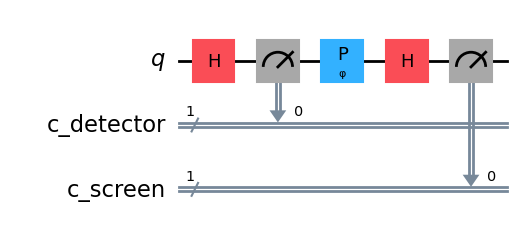

In [34]:
qr = QuantumRegister(1, name='q')
cr1 = ClassicalRegister(1, name='c_detector')
cr2 = ClassicalRegister(1, name='c_screen')
double_slit_with_detector = QuantumCircuit(qr, cr1, cr2)

φ = Parameter('φ')

# 以下にコードを記述してください

double_slit_with_detector.h(0)
double_slit_with_detector.measure(qr, cr1)

double_slit_with_detector.p(φ, 0)
double_slit_with_detector.h(0)
double_slit_with_detector.measure(qr, cr2)

# コードはここまでです

double_slit_with_detector.draw('mpl')

In [35]:
# 次のコードを実行して、課題を提出してください
grade_lab1_ex3(double_slit_with_detector)

Submitting your answer. Please wait...
Congratulations! 🎉 Your answer is correct.


次に、ヒートマップ生成を繰り返して、検出器で新しいパターンを確認してください。

**警告**：これには数分かかることがあります


<div class="alert alert-block alert-warning">
<b>リソース制約</b>

以下のコードを実際のバックエンドで実行する場合、パラメータまたはショットの数を増やすと、予想よりも多くの QPU 時間が消費されます。現在の構成（100 個のパラメータ回路 + 1000 ショット）では、QPU 時間の消費は1分未満のため、可能であればこの設定を維持してください。

</div>


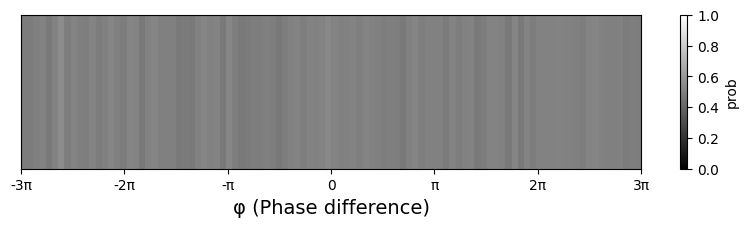

In [36]:
φ_lst = np.linspace(-3 * np.pi, 3 * np.pi, 100)
qc_isa = pm.run(double_slit_with_detector)

φ_hit = []
dist = sampler.run([(qc_isa, φ_lst)], shots=1000).result()[0].data.c_screen

for i  in range(len(φ_lst)):
    result = dist[i].get_counts()
    if '0' in result:
        φ_hit.append(result['0']/1000)
    else:
        φ_hit.append(0)

φ_hit_2d = np.array(φ_hit).reshape(1, -1)

plt.figure(figsize=(10, 2))
plt.imshow(φ_hit_2d, cmap='gray', aspect='auto', extent=[-3*np.pi, 3*np.pi, 0, 0.1], vmin=0, vmax=1)

plt.xlabel('φ (Phase difference)', fontsize=14)
plt.colorbar(label='prob')
plt.xticks(ticks=[-3 * np.pi, -2 * np.pi, -np.pi, 0, np.pi, 2 * np.pi, 3 * np.pi],
           labels=['-3π', '-2π', '-π', '0', 'π', '2π', '3π'])
plt.yticks([])  
plt.show()

$\phi$ に関係なく、$|\psi_0\rangle$ を測定する確率が約50％であることを示す、ほとんど灰色のパターンが表示されます。干渉縞が消えました！

<details> 
<summary> <h3>検出器の仕組みを調べる</h3> </summary>

1. **初期状態**：$|\psi_0\rangle = |0\rangle$
2. **最初のHゲート**：$|\psi_1\rangle = \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)$ 
    量子ビットは重ね合わせ状態にあります。
3. **最初の測定（検出器）**：重ね合わせを崩壊させます。
    * 結果が0（確率 1/2）$\rightarrow |\psi_{2a}\rangle = |0\rangle$
    * 結果が1（確率 1/2）$\rightarrow |\psi_{2b}\rangle = |1\rangle$
    量子ビットは現在確定的な状態です。
4. **Pゲート**：
    * 結果が0の場合: $|\psi_{3a}\rangle = P(\phi)|0\rangle = |0\rangle$
    * 結果が1の場合: $|\psi_{3b}\rangle = P(\phi)|1\rangle = e^{i\phi}|1\rangle$
    位相　$\phi$　は、状態の崩壊のため、干渉に必要な *相対* 位相として機能することはできません。
5. **2番目のHゲート**：
    * 結果が0の場合: $|\psi_{4a}\rangle = H|0\rangle = \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)$
    * 結果が1の場合: $|\psi_{4b}\rangle = H(e^{i\phi}|1\rangle) = e^{i\phi} \frac{1}{\sqrt{2}}(|0\rangle - |1\rangle)$
6. **2番目の測定（スクリーン）**：
    * 最初の測定が0の場合: Prob(final '0') = 1/2, Prob（final '1'）= 1/2
    * 最初の測定が1の場合: Prob(final '0') = 1/2, Prob（final '1'）= 1/2

**結論**：検出器の結果に関係なく、最終測定は常に $|0\rangle$ または $|1\rangle$ で50/50です。中間測定により重ね合わせは壊れ、それにより干渉が消失しました。これは、「どちらの経路を通るか」という情報が干渉を破壊することを示しています。
</details> 


ここまで、重ね合わせ、干渉、測定を調査しました。それでは、別の深遠な量子現象である**エンタングルメント**に飛び込みましょう。


# 第2章： エンタングルメント

**量子エンタングルメント**とは、粒子同士が相互に結びつき、距離に関係なく量子状態を共有する現象です。一方の粒子の状態を測定することで、もう一方の粒子の状態について即座に情報が得られます。アインシュタインはこれを「spooky action at a distance (不気味な遠隔作用)」と呼んだ。

1964年、ジョン・ベルは、エンタングルされた粒子が古典的に振る舞うかどうかを検証するために「ベルの不等式（Bell’s inequality）」を提案しました。「CHSH実験」はその具体的な検証方法を提供しました。結果は量子力学が古典的な期待を覆し、正しさを証明するものでした[3]。 1997年には、エンタングルメントを利用して粒子を移動させずに量子状態だけを転送する「量子テレポーテーション」が実現されました[4]。

Qiskit を使用して、CHSH実験と量子テレポーテーションを試してみましょう！


## 2.1. アリスとボブと無敵のゲーム：　CHSHゲームの奇妙なケース

アリスとボブは遠く離れており、互いに通信することはできません。審判が次のような課題を出します：
1。審判は2つのビット（`x`,`y`）を選び、アリスに `x` を、ボブに `y` を送ります。
2。アリスとボブはビット（`a`,`b`）を即座に返信します。
3。**勝利条件**： `a XOR b == x　AND y`

アリスとボブは、平均勝率を最大化するために、事前に戦略を決めておきたいと考えています。

**目標**：Qiskit を使用して CHSH ゲームの*量子*戦略を実装し、その性能をシミュレートして古典戦略の限界と比較することで、量子エンタングルメントによって提供される優位性を理解しましょう。 


<div class="alert alert-block alert-info">
<b>詳細な研究のために</b>

CHSHゲームを含むエンタングルメントの実践的な説明については、Qiskitの学習リソース [Entanglement in Action](https://quantum.cloud.ibm.com/learning/courses/basics-of-quantum-information/entanglement-in-action/introduction) を参照してください。
</div>


### 古典的な限界： なぜ75％が壁なのか

まずは古典的な場合を考えてみましょう。アリスとボブは `x` と `y` を受け取った後に通信できないため、アリスの出力 `a` は `x` のみに、ボブの出力 `b` は `y` のみに依存します。事前に戦略（ランダム戦略を含む）を合意することはできますが、最終的には各自のローカルな選択に帰着します。

勝利条件を整理すると以下のようになります：

* 入力が (0,0), (0,1), (1,0) のとき： `a == b` なら勝利
* 入力が (1,1) のとき： `a != b` なら勝利

例えば `a = 0, b = 0` や `a = x, b = y` のような固定戦略を試してみてください。4通りの入力に対して、3回以上勝つような戦略は存在しないことがわかるでしょう。

このように、**平均勝率の上限はどう頑張っても75%**。これは「局所実在論（local realism）」が持つ根本的な限界なのです。

### 量子戦略：エンタングルメントが切り札！

もしアリスとボブがゲーム**開始前**に、何か特別な準備をしていたらどうでしょう？例えば、**エンタングル状態の量子ビット**を共有していたとしたら？エンタングルメントは、あたかも2枚の「魔法のコイン」のようなものです。どんなに離れていても、一方を測定すれば、もう一方の測定結果との**相関関係**が即座に現れます。これは光速を超えて情報を送っているわけではなく、単に結果の出方が不思議なほどリンクしているのです。

アリスとボブが共有しているのは、次のような[ベル状態](https://en.wikipedia.org/wiki/Bell_state)です：$(|00\rangle + |11\rangle) / \sqrt{2}$  
この状態では、**同じ方法で測定**すれば、必ず同じ結果（両方0または両方1）になります。

量子戦略:  
固定ビットを出力するのではなく、アリスとボブはそれぞれの入力（`x` または `y`）に応じて、共有している量子ビットを**どのように**測定するか決定します。
1. 共有リソース：アリスは量子ビット 0、ボブは量子ビット 1を保持しており、それらはベル状態でエンタングルされています。
2. **測定の選択（ここがミソ！）：**
   * アリス（入力 `x`）： `x=0` のとき角度 0（Z基底）で測定、または `x=1` のとき角度 π/2（X基底）で測定します。
   * ボブ（入力 `y`）： `y=0` のとき角度 -π/4 で、または `y=1` のとき角度 π/4 で `Ry` ゲートを使って測定します。
3. 出力：各自の測定結果をそのまま `a` と `b` として返します。

これらの角度は決して適当ではなく、ベル状態が持つ独特の相関を最大限に活かし、全ての入力組み合わせに対して `a XOR b == x AND y` という勝利条件を最大限満たせるよう設計されています。

さあ、この戦略に基づいた量子回路を構築してみましょう。

アリスとボブは $(|00\rangle + |11\rangle) / \sqrt{2}$ の状態を共有しており、同じ方法で測定すれば常に同じ結果が得られるという性質を持っています。

**補足**

この量子回路の構成、動作フロー、またその原理に関する詳細は、以下の IBM Quantum Learning コースの[こちらのレッスン(Basics of Quantum Information)](https://learning.quantum.ibm.com/course/basics-of-quantum-information/entanglement-in-action#the-chsh-game)を参照してください。


### Qiskit 実装： 量子回路の構築

<div class="alert alert-block alert-success">
<b>Exercise 4：CHSH ゲームの量子回路</b>

**目標：** `create_chsh_circuit(x、y)` という関数を定義してください。これはアリスとボブが CHSH ゲームで量子戦略に使用する量子回路を構築することでできます。これには、エンタングルしたベル状態を準備し、それぞれの入力に基づいて測定規定の回転を適用することが含まれます。

**タスク：**
* **タスク1：** ベル状態$(|00\rangle + |11\rangle) / \sqrt{2}$ を作成します。
* **タスク2：** 入力 `y` に基づいてボブの回転を実装します。
</div>


In [51]:
import math

def create_chsh_circuit(x, y):
    """Builds Qiskit circuit for Alice & Bob's quantum strategy."""
    qc = QuantumCircuit(2, 2, name=f'CHSH_{x}{y}') # 2量子ビット, 2古典ビット

    # ---- TODO： Task 1 ---
    # ベル状態 |Φ+> = (|00> + |11>)/sqrt(2) を作成するゲートを実装
    qc.h(0)
    qc.cx(0, 1)



    # --- End of TODO ---
    qc.barrier()
    # Step 2a: アリスの測定基底 (x=1ならX基底, x=0ならZ基底)
    if x == 1:
        qc.h(0) # X-基底測定のためのH

    ##  --- TODO：Task 2 ----
    # Step 2b: ボブの測定基底　
    # y=0 のとき角度 -π/4 で、または y=1 のとき角度 π/4 で Ry ゲートを使って測定
    if y == 0:
        qc.ry(-math.pi / 4.0, 1)
    elif y == 1:
        qc.ry(math.pi / 4.0, 1)



    # --- End of TODO ---
    qc.barrier()
    
    # Step 3: 測定
    qc.measure([0, 1], [0, 1]) # q0 を c0 (アリス), q1 を c1 (ボブ) -> 'ba' 形式

    return qc

#qc = create_chsh_circuit(1, 1)
#qc.draw('mpl')

In [52]:
# 次のコードを実行して、課題を提出してください
grade_lab1_ex4(create_chsh_circuit)

Submitting your answer. Please wait...
Congratulations! 🎉 Your answer is correct.


### すべての入力ペアの回路を作成

ここで、実装した関数を使用して、4つの（x、y）シナリオすべての回路を生成しましょう。

Quantum circuit for inputs x=1, y=1 (Check your Exercises 1 & 2 implementation):


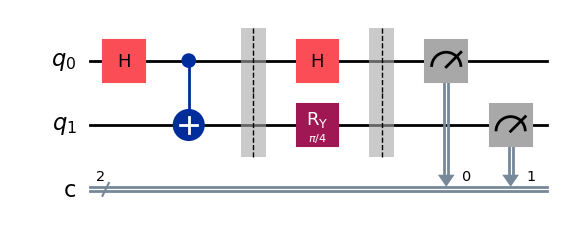

In [53]:
circuits = []
input_pairs = []
for x_in in [0, 1]:
    for y_in in [0, 1]:
        input_pairs.append((x_in, y_in))
        circuits.append(create_chsh_circuit(x_in, y_in))

print("Quantum circuit for inputs x=1, y=1 (Check your Exercises 1 & 2 implementation):")
if len(circuits) == 4:
    display(circuits[3].draw('mpl')) # (x,y) = (1,1)
else:
    print("Circuits not generated. Run previous cell after completing Exercises 1 & 2.")

### シミュレーション：ゲームを何度もプレイ

実際の量子コンピューターはノイズが多かったり、アクセスが難しい場合があります。ありがたいことに、このような小さなシステムについては、振る舞いを非常に正確にシミュレートすることができます。 Qiskit の`Aersimulator` を使用して、4つの回路を何度も実行し（「ショット」）、アリスとボブの出力（`a`と`b`）に関する統計を収集します。

Preparing circuits for the simulator...

--- Simulation Results (Counts) ---
Inputs (x=0, y=0):
  Outcomes (ba): {'00': 451, '01': 72, '10': 89, '11': 412}
Inputs (x=0, y=1):
  Outcomes (ba): {'00': 441, '01': 82, '10': 76, '11': 425}
Inputs (x=1, y=0):
  Outcomes (ba): {'00': 449, '01': 83, '10': 69, '11': 423}
Inputs (x=1, y=1):
  Outcomes (ba): {'00': 68, '01': 457, '10': 433, '11': 66}

Plotting results...


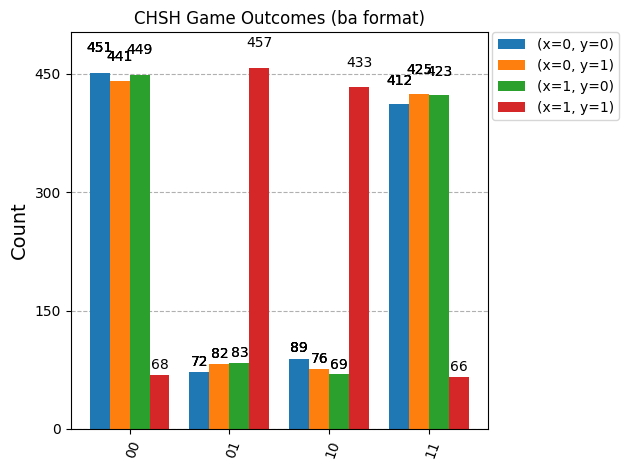

In [54]:
# AerSimulator (未定義の場合)
# backend = AerSimulator()
# Pass manager (未定義の場合)
# pm = generate_preset_pass_manager(backend=backend, optimization_level=1)

SHOTS = 1024

print("Preparing circuits for the simulator...")
isa_qc_chsh = pm.run(circuits)

sampler_chsh = Sampler(mode=backend) # SamplerV2
job_chsh = sampler_chsh.run(isa_qc_chsh, shots=SHOTS)
results_chsh = job_chsh.result()

# SamplerV2: results_chsh[i].data.c.get_counts() where 'c' is the default name of classical register
counts_list = [results_chsh[i].data.c.get_counts() for i in range(len(circuits))]

print("\n--- Simulation Results (Counts) ---")
for i, (x, y) in enumerate(input_pairs):
    print(f"Inputs (x={x}, y={y}):")
    sorted_counts = dict(sorted(counts_list[i].items()))
    print(f"  Outcomes (ba): {sorted_counts}")

print("\nPlotting results...")
display(plot_histogram(counts_list,
                       legend=[f'(x={x}, y={y})' for x, y in input_pairs],
                       title='CHSH Game Outcomes (ba format)'))

### 分析： 古典的な限界を突破したか？

今、真実の瞬間！平均勝利確率を計算するには、シミュレーション結果（`counts_list`）を分析する必要があります。

**要約：**
* **勝利条件**: `a XOR b == x AND y`
* **出力形式**: カウントは `'ba'`文字列の場合です。
    * `a XOR b = 0` の結果 `'00'`（`b = 0, a = 0`）および `'11'`（`b = 1、a = 1`）
    * `a XOR b = 1` の結果 `'01'`（`b = 0、a = 1`）および `'10'`（`b = 1、a = 0`）


<div class="alert alert-block alert-success">
<b>Exercise 5: CHSHゲームの回路を分析</b>

**あなたの目標**： シミュレーション結果に基づいて、各入力ケース（`x`,`y`）のアリスとボブの勝利確率を計算し、量子戦略を使用して全体の平均勝利確率を決定してください。

**タスク：**
* **タスク1：** `x` と `y` から与えられた勝利のターゲット `a XOR b` の値を決定します。
* **タスク2：** 勝利条件を満たすショット（`wins_for_this_case`）をカウントします。
</div>


In [55]:
counts_list

[{'10': 89, '00': 451, '11': 412, '01': 72},
 {'01': 82, '00': 441, '11': 425, '10': 76},
 {'11': 423, '01': 83, '00': 449, '10': 69},
 {'10': 433, '01': 457, '00': 68, '11': 66}]

In [60]:
win_probabilities = {}
print("--- Calculating Win Probabilities ---")

for i, (x, y) in enumerate(input_pairs):
    counts = counts_list[i]

    # ---- TODO : Task 1 ---
    # 勝利条件を決定するためのターゲット値（a XOR b）を計算
    if x == 1 and y == 1:
        target_xor_result = 1
    else:
        target_xor_result = 0

    # --- End of TODO --

    wins_for_this_case = 0

    # ---- TODO : Task 2 ---
    # 上記で決定した勝利条件を満たすショットの総数を計算（'target_xor_result'をチェック）
    for ba in counts:
        a = 0 if ba[1] == '0' else 1
        b = 0 if ba[0] == '0' else 1
        if a ^ b == target_xor_result:
            wins_for_this_case += counts[ba]

    # --- End of TODO --

    prob = wins_for_this_case / SHOTS if SHOTS > 0 else 0
    win_probabilities[(x, y)] = prob
    print(f"Inputs (x={x}, y={y}): Target (a XOR b) = {target_xor_result}. Win Probability = {prob:.4f}")

avg_win_prob = sum(win_probabilities.values()) / 4.0
P_win_quantum_theory = np.cos(np.pi / 8)**2  # ~0.8536
P_win_classical_limit = 0.75

print("\n--- Overall Performance ---")
print(f"Experimental Average Win Probability: {avg_win_prob:.4f}")
print(f"Theoretical Quantum Win Probability: {P_win_quantum_theory:.4f}")
print(f"Classical Limit Win Probability:     {P_win_classical_limit:.4f}")

if avg_win_prob > P_win_classical_limit + 0.01: # Allow for small simulation variance
    print(f"\nSuccess! Your result ({avg_win_prob:.4f}) clearly beats the classical 75% limit!")
    print(f"It's likely close to the theoretical quantum prediction of {P_win_quantum_theory:.4f}.")
elif avg_win_prob > P_win_classical_limit - 0.02 : # Could be noise or minor error
     print(f"\nClose, but no cigar? Your result ({avg_win_prob:.4f}) is around the classical limit ({P_win_classical_limit:.4f}).")
     print("Check your solutions for Exercises 1-4 carefully, especially the win counting logic in Ex 4.")
else:
    print(f"\nHmm, the result ({avg_win_prob:.4f}) is unexpectedly low, even below the classical limit.")
    print("There might be an error in Exercises 1-4. Please review your circuit and analysis code.")

--- Calculating Win Probabilities ---
Inputs (x=0, y=0): Target (a XOR b) = 0. Win Probability = 0.8428
Inputs (x=0, y=1): Target (a XOR b) = 0. Win Probability = 0.8457
Inputs (x=1, y=0): Target (a XOR b) = 0. Win Probability = 0.8516
Inputs (x=1, y=1): Target (a XOR b) = 1. Win Probability = 0.8691

--- Overall Performance ---
Experimental Average Win Probability: 0.8523
Theoretical Quantum Win Probability: 0.8536
Classical Limit Win Probability:     0.7500

Success! Your result (0.8523) clearly beats the classical 75% limit!
It's likely close to the theoretical quantum prediction of 0.8536.


In [61]:
# 次のコードを実行して、課題を提出してください
grade_lab1_ex5(counts_list, avg_win_prob)

Submitting your answer. Please wait...
Congratulations! 🎉 Your answer is correct.


### 結論：量子の優位性

では、何が分かったのでしょうか？演習をうまく完了できた場合、あなたのシミュレーション結果は、アリスとボブがエンタングルされた量子ビットと巧妙な測定方法を用いることで、古典的な限界である75%を**大きく超える**勝率を達成できたことを示しているはずです。
理論上の量子的最大勝率である 約**85.4%** に近づいていることでしょう。

これは単なる数学的なトリックではなく、自然界の最も基本的な性質を反映しています。エンタングルメントは、古典物理学では説明できないほど強い、遠く離れた粒子間の相関を可能にします。この「遠隔作用の不気味な現象（spooky action at a distance）」は、光速を超えた通信を可能にするものではありませんが、多くの量子技術の基盤となっています。

**考察ポイント：**
今回の結果をふまえて、CHSHゲームは古典的直感と比べて現実の本質がどう異なるかを何と語っているのでしょうか？また、この古典を超える相関が役立ちそうな応用例を、何か思いつきますか？

## 2.2. 量子テレポーテーション ― 不気味な力で秘密を送信する

アリスが量子ビット `q0` を持っていて、それがある特定の繊細な量子状態 `|ψ⟩` にあるとします。彼女はこのまったく同じ状態を、遠く離れたボブに送りたいと考えています。でも、量子ビット自体を物理的に送ることはできません（たとえば、壊れやすすぎる、あるいはオリジナルの粒子を保持しておきたい、などの理由で）。
では、「*状態だけ*」を送ることはできるのでしょうか？

古典的には、これは不可能に思えます。アリスが自分の量子ビットの状態を「測定」した時点で、重ね合わせは崩壊し、元の状態は失われてしまうからです。

そこで登場するのが **量子テレポーテーション**！これは、**量子エンタングルメント**と**古典的通信**を組み合わせることで、未知の量子状態を一方の量子ビットから他方の量子ビットへ転送できる、驚くべきプロトコルです。

**注意：** テレポートされるのは「状態」であり、「物質」ではありません！実際に人が転送されるわけではありませんのでご安心を。

**あなたの目標：**
このラボでは、Qiskit を使って量子テレポーテーションのプロトコルを実装します。必要な量子リソースの準備、主要なステップの実行、そして最終的にボブがアリスの量子状態を正しく受け取ったことを確認するコードを完成させましょう。

### テレポーテーション・プロトコル：ステップバイステップ

このプロトコルでは、3つの量子ビットと2つの古典ビットを使用します：
* **`q0`：** アリスの量子ビットで、テレポートしたい状態 `|ψ⟩` に初期化されています
* **`q1`：** アリスが持つ、エンタングルメント対の片方
* **`q2`：** ボブが持つ、エンタングルメント対のもう片方
* **`c0`, `c1`：** アリスの測定結果を格納する古典ビット

こちらが計画です：
1. **（任意）アリスの状態 `|ψ⟩` を `q0` に準備**
　（検証のために `|+⟩` のような特定の状態を作成します）
2. **エンタングルメントの生成：**
   　`q1` と `q2` の間にベル状態を作成します
3. **アリスの操作：**
   　アリスは `q0` と `q1` に「ベル測定」を行い、その結果を `c0` と `c1` に格納します
4. **古典通信：**
   　アリスは自分の測定結果（`c0`, `c1`）をボブに送信します
5. **ボブの補正操作：**
   　ボブは `c0`, `c1` に基づき、自身の量子ビット `q2` に以下の操作を行います：
   * `c1 = 1` のとき → `q2` に **Xゲート**
   * `c0 = 1` のとき → `q2` に **Zゲート**

すべて正しく実行されれば、ボブの量子ビット `q2` は、アリスの `q0` が持っていた状態 `|ψ⟩` とまったく同じ状態になります！

<div class="alert alert-block alert-info">
<b>より深く学ぶために</b>  
量子テレポーテーションの詳細な解説や応用例については、以下のQiskitの学習リソースをご参照ください： 

[Quantum Teleportation](https://learning.quantum.ibm.com/course/basics-of-quantum-information/entanglement-in-action#teleportation)

（John Watrous による [Basics of Quantum Information](https://learning.quantum.ibm.com/course/basics-of-quantum-information) コースの [Entanglement in Action](https://learning.quantum.ibm.com/course/basics-of-quantum-information/entanglement-in-action) の一部）
</div>


### ツール： Qiskit ダイナミック・サーキット

アリスの測定結果に応じてボブが操作を変えるには、ダイナミック・サーキットを使用します。これにより、量子回路の途中で得た古典情報（測定結果）を使って、その後の量子操作に影響を与えることができます。この機能は、量子テレポーテーションのようなプロトコルや、長距離エンタングルメントの効率的な生成に不可欠です。
（例：Bäumer et al., PRX QUANTUM 5, 030339 (2024)）

**参考リンク：**

* [Qiskit：古典フィードフォワードと制御フローのドキュメント](https://quantum.cloud.ibm.com/docs/guides/classical-feedforward-and-control-flow)
* [Efficient Long-Range Entanglement Using Dynamic Circuits (PRX Quantum)](https://journals.aps.org/prxquantum/abstract/10.1103/PRXQuantum.5.030339)

### テレポーテーションで重要な概念：

1. **回路途中での測定**
   * Qiskit では、回路の任意の時点で量子ビットを測定し、その結果を古典ビットに格納できます
   * アリスは `q0` と `q1` を測定し、`c0`, `c1` に記録します
   * 使用命令：`QuantumCircuit.measure(qubit, classical_bit)`

2. **条件付き操作（`if_test`）**
   * ボブはアリスの `c0`, `c1` を受け取り、それに応じて `q2` に量子ゲートを適用します
   * Qiskit では、古典ビットの値に基づいてゲートを適用できます
   * 方法：
     * `QuantumCircuit.if_test((classical_bit, value), true_circuit)`（新しいQiskit）
     * `gate.c_if(classical_bit, value)`（古い方法）
   * 今回の補正：
     * `c1 = 1` (`cr_alice_tele[1]`) のとき `q2` に Xゲート
     * `c0 = 1` (`cr_alice_tele[0]`) のとき `q2` に Zゲート

これらの機能により、量子テレポーテーションのような古典通信と量子操作の融合が、1つの量子回路として直接記述・シミュレーション可能になります。

メモ: 条件付きゲートの順序を忘れないでください！量子コンピューティングでは $AB != BA$ なので、順序が重要です。


### Qiskit でテレポーテーション回路を構築する


<div class="alert alert-block alert-success">
<b>Exercise 6：量子テレポーテーション</b>

**あなたの目標**: アリスのメッセージ量子ビットからボブの量子ビットへ未知の量子状態をテレポートするための完全な量子回路を構築してください。その際、エンタングル状態のベルペアと、条件操作を伴う回路途中での測定を利用してください。

**タスク：**
* **ステップ 1**： 共有されたエンタングル状態のベルペア $(|00\rangle + |11\rangle) / \sqrt{2}$ を `q1`と`q2`の間で作成します。
* **ステップ 2**： アリスのベル測定ゲートを実装します（実際の測定前）。
* **ステップ 3**： アリスの測定結果に基づいて、ボブの条件付き修正ゲートを実装します。
</div>


Full Teleportation Circuit (Check your Exercises 1, 2, 3):


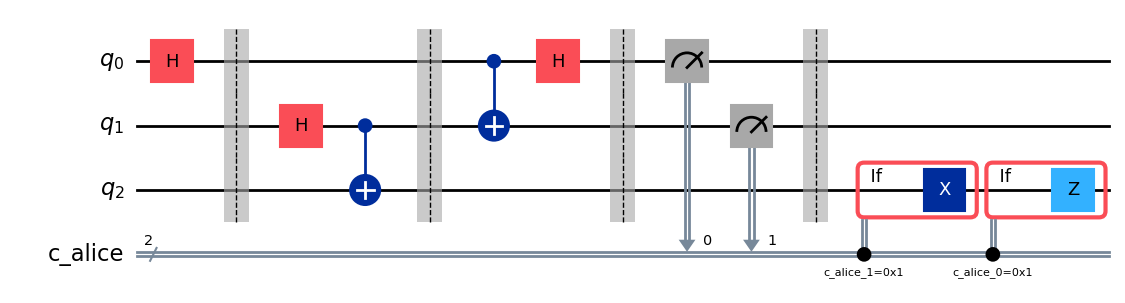

In [63]:
# 量子と古典レジスタを定義
qr_tele = QuantumRegister(3, name='q')
cr_alice_tele = ClassicalRegister(2, name='c_alice') # アリスの測定用

# 状態ベクトルでの検証用に、ボブの最終量子ビットはこの回路では測定しません。
# ハードウェアで実行してカウントで検証する場合は、ボブ用の古典ビットを追加します。
teleport_qc = QuantumCircuit(qr_tele, cr_alice_tele, name='Teleportation')

# アリスのメッセージ状態 |ψ> = |+> を q0 に準備
teleport_qc.h(qr_tele[0])
teleport_qc.barrier()

# ---- TODO : Task 1 ---
# Step 1: ベルペアを q1 (アリス) と q2 (ボブ) の間に作成
teleport_qc.h(qr_tele[1])
teleport_qc.cx(qr_tele[1], qr_tele[2])

# --- End of TODO --
teleport_qc.barrier()

# ---- TODO : Task 2 ---
# Step 2: アリスのベル測定 (ゲート部分)
teleport_qc.cx(qr_tele[0], qr_tele[1])
teleport_qc.h(qr_tele[0])

# --- End of TODO --
teleport_qc.barrier()

# アリスの q0 と q1 を測定
teleport_qc.measure(qr_tele[0], cr_alice_tele[0]) # q0 -> c0
teleport_qc.measure(qr_tele[1], cr_alice_tele[1]) # q1 -> c1
teleport_qc.barrier()

# ---- TODO : Task 3 ---
# Step 3: ボブの q2 に対する条件付き補正
# c1 = 1 (cr_alice_tele[1]) のとき q2 に Xゲート
# c0 = 1 (cr_alice_tele[0]) のとき q2 に Zゲート
with teleport_qc.if_test((cr_alice_tele[1], 1)):
    teleport_qc.x(qr_tele[2])
with teleport_qc.if_test((cr_alice_tele[0], 1)):
    teleport_qc.z(qr_tele[2])


# --- End of TODO --

print("Full Teleportation Circuit (Check your Exercises 1, 2, 3):")
display(teleport_qc.draw('mpl'))

In [64]:
# 次のコードを実行して、課題を提出してください
grade_lab1_ex6(teleport_qc)

Submitting your answer. Please wait...
Congratulations! 🎉 Your answer is correct.


### シミュレーションと検証

テレポーテーションがうまくいったかどうかを、どうやって検証すればよいのでしょうか？量子ビット `q2` の状態を直接“見る”ことはできません。
しかし、アリスの初期状態 `|ψ⟩`（ここでは `|+⟩` を選びました）を自分で準備したので、それを使って検証する方法があります。

ここでは `AerSimulator` を用いて、`save_statevector` によって最終的な量子状態ベクトルを確認します。このシミュレータは回路実行後の状態ベクトルを出力できるため、ボブの量子ビット `q2` が本当にアリスの元の状態 `|+⟩` に一致しているかどうかを確認できます。

<div class="alert alert-block alert-success">
<b>Exercise 7（採点なし）：量子テレポーテーションの結果を分析</b>

**あなたの目標：**
シミュレーションによって、アリスの量子状態がボブの量子ビットに正しくテレポートされたことを検証し、最終状態を可視化しましょう。

**タスク：**
* 最終状態ベクトルを抽出し、`plot_bloch_multivector` を使ってボブの量子ビット（`q2`）の状態を可視化してください。それをアリスの初期状態（`q0` に用意した `|+⟩`）と比較してください。
</div>


Using statevector simulator...
Running statevector simulation...
Simulation successful.
Statevector retrieved successfully.

Visualizing final qubit states (q2 should match initial q0 state |+>):
Statevector([ 0.        +0.00000000e+00j,  0.70710678+0.00000000e+00j,
              0.        +0.00000000e+00j, -0.        +0.00000000e+00j,
             -0.        +0.00000000e+00j,  0.70710678-8.65956056e-17j,
             -0.        +0.00000000e+00j, -0.        +0.00000000e+00j],
            dims=(2, 2, 2))


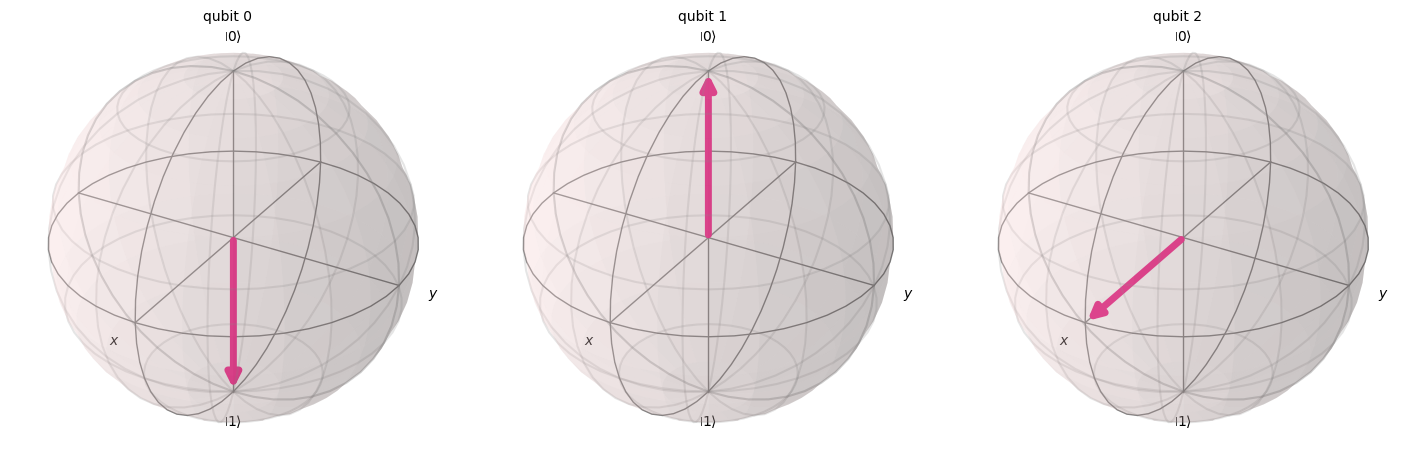

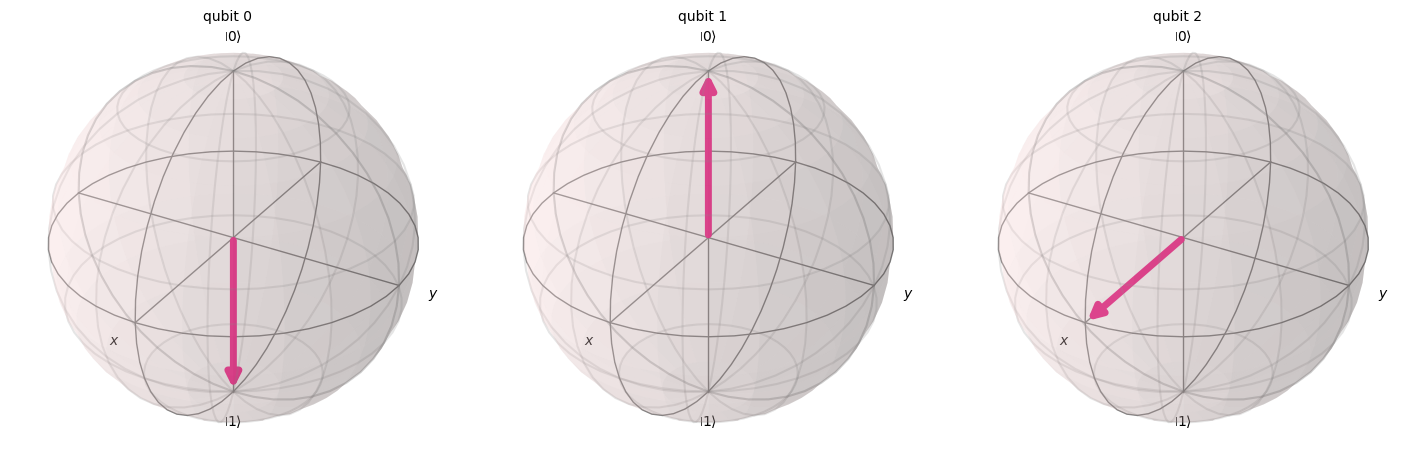

In [70]:
%matplotlib inline

import qiskit.visualization

# Use Statevector Simulator
print("Using statevector simulator...")
sv_simulator = AerSimulator(method='statevector') # Explicitly set method for clarity
teleport_qc_sv = teleport_qc.copy() # Work with a copy for statevector simulation
teleport_qc_sv.save_statevector() # Save statevector at the end

print("Running statevector simulation...")
job_sv = sv_simulator.run(teleport_qc_sv) # shots=1 is default for statevector
result_sv = job_sv.result()

if result_sv.success:
    print("Simulation successful.")
    final_statevector = result_sv.get_statevector()
    print("Statevector retrieved successfully.")
    print("\nVisualizing final qubit states (q2 should match initial q0 state |+>):")
    # q0 was |+> (points along +X). After teleportation, q2 should be |+>.
    # q0 and q1 states are after Alice's measurement, so they'll be collapsed.

    print(final_statevector)
    
    display(qiskit.visualization.plot_bloch_multivector(final_statevector)) #TODO, use plot_bloch_multivector to plot final_state
    
        
else:
    print(f"Statevector simulation failed! Status: {result_sv.status}")

### 結果の解釈

Exercise 6 が正しかった場合は、次のように表示されます。
* `Q0`（アリスのオリジナル）：ランダム状態（測定によって崩壊）
* `q1`（アリスのエンタングルメント）：ランダム状態（測定によって崩壊）
* `q2`（ボブのエンタングルメント）：**プラスのX軸**に沿ったブロッホ球のベクトル。これは `|+>` 状態で、アリスの最初の `q0` と一致します！

**成功！** `|ψ⟩ = |+⟩` へ状態がテレポートされました。

### 結論：エンタングルメントと情報の魔法

私たちは量子テレポーテーションプロトコルの実装に成功しました！

主なポイント:
* テレポーテーションは、未知の量子状態を共有エンタングルメントと古典通信を使って転送します。
* 物理的な粒子自体を転送するわけではありません。
* アリスの量子ビット上の元の状態は消滅します（ノー・クローニング定理と一致）。
* 古典通信（アリスの測定結果をボブに送る）が必要なので、光より速い情報伝達はできません。

量子テレポーテーションは、量子通信や量子計算の基礎となる技術です。

**ディスカッションポイント**：なぜアリスは単に`q0`を測定（例えばZ基底とX基底で）して、その結果をボブに送って再現してもらうことができないのでしょうか？テレポーテーションと何が違うのでしょうか？

In [71]:
# 以下のコードを実行して、課題の提出状況を確認してください
from qc_grader.grader.grade import check_lab_completion_status
check_lab_completion_status("qgss_2025")

Lab 0: 2/2 exercises completed (100%)
    ✅ 2005 participants have completed this lab
Lab 1: 9/9 exercises completed (100%)
    ✅ 1332 participants have completed this lab
Lab 2: 0/7 exercises completed (0%)
    ✅ 617 participants have completed this lab
Lab 3: 0/5 exercises completed (0%)
    ✅ 242 participants have completed this lab
Lab 4: 0/6 exercises completed (0%)
    ✅ 0 participants have completed this lab
Functions Labs: 0/8 exercises completed (0%)
    ✅ 0 participants have completed this lab


# （ボーナスチャレンジ）実機でのテレポーテーション

シミュレーター上でテレポーテーションが完璧に動作することを確認しました。次は、**実際のIBM Quantum バックエンド**で試してみましょう！ここからが量子コンピューティングの本当の挑戦と興奮の始まりです。実機にはノイズがあり、量子ビットの接続にも制限があります。

<div class="alert alert-block alert-warning">
<b>Dynamic Circuits がアップグレード中です！</b>

現在、実際のハードウェアでダイナミック・サーキットがアップグレード中で、あなたは新しいバージョンをテストできる最初の人の一人です！
ただし、この早期アクセスにはいくつかの注意点があります：
* 1. 早期アクセスを有効にするために、追加のコード行を設定する必要があります（以下を参照）。
* 2. この早期アクセスは、with...（例：with Batch(...)）を使用したセッションやバッチでは動作しません。ただし、プリミティブに直接渡すことはできます（例：Sampler(mode=batch)）。
* 3. if_test 条件で 32 ビットを超える ClassicalRegister を使用できません。ただし、複数の ClassicalRegister を使用することはできます（各々 <=32 ビット）。
* 4. ネストされた条件は使用できません。
* 5. 条件ブロック内に measure や reset を含めることはできません。

</div>

実際のハードウェアでダイナミック・サーキットを使用するには、2つのステップが必要です。


ステップ 1: 使用するハードウェアに命令を追加する必要があります

 ```python
    # (1) Patch the backend target with IfElseOp
    from qiskit.circuit import IfElseOp
    backend.target.add_instruction(IfElseOp, name="if_else")
        
```




ステップ 2: ジョブを送信するときに実験的オプションを有効にする必要があります

 ```python
    #(2) Submit the job with the experimental option
    sampler.options.experimental = {"execution_path" : "gen3-experimental"}
        
```

### ダイナミックサーキット：実機の鍵

テレポーテーションプロトコルは本質的に**ダイナミックサーキット**を必要とします。アリスが自分の量子ビットを測定し、その結果をボブに*古典的に通信*して、ボブがどの補正ゲートを自分の量子ビットに適用するかを決定します。Qiskit は「途中測定」や「古典フィードフォワード」操作を可能にします。

最近の研究（例：Bäumer et al. "Efficient Long-Range Entanglement Using Dynamic Circuits"（PRX QUANTUM 5, 030339 (2024)））では、ダイナミックサーキットの威力が示されています。CNOT ゲートのテレポーテーションや長距離 GHZ 状態の生成などのタスクで、ダイナミックサーキットは純粋なユニタリー回路よりも大規模デバイスで優れた性能を発揮し、量子回路の深さを距離に関係なく一定に保つことができます。

私たちのテレポーテーションプロトコルでも、ダイナミックサーキットによりアリスの測定結果がリアルタイムでボブのゲート操作に反映されます。IBM Quantum バックエンドへのアクセスは**IBM Cloud**経由で行います。IBM Cloud アカウントと Quantum サービスの有効化が必要です。

### チャレンジ：どこまで遠くに送れるか？

**あなたの目標：** 実際の IBM Quantum バックエンド上で、0番目の量子ビット（アリスのメッセージ）から別の量子ビット（ボブ）へ、例えば $|+\rangle$ 状態をテレポートしてください。Qiskit のダイナミックサーキットを使い、できればチップ上で直接つながっていない量子ビット同士を選びましょう。テレポーテーションの忠実度を観測・報告し、改善にも挑戦してみてください！

**実機での実行の基本ステップ：**

詳細はlab0にもありますが、ここでは要点をまとめます。

1.  IBM Quantum へのアクセス設定（IBM Cloud 経由）:
    * アカウントがなければ IBM Cloud アカウントを作成し、Quantum サービスを有効化してください。
    * IBM Cloud の Quantum ダッシュボードから API トークンを取得します。
    * `QiskitRuntimeService` を使ってアカウントを保存し、利用可能なバックエンドを一覧表示します。

       ```python
        from qiskit_ibm_runtime import QiskitRuntimeService
        QiskitRuntimeService.save_account(channel="ibm_quantum_platform", token="YOUR_IBM_CLOUD_API_TOKEN", instance="YOUR_CRN_INSTANCE_ID_OR_CLOUD_INSTANCE_NAME", overwrite=True)
        service = QiskitRuntimeService(channel="qgss-2025")
        print(service.backends())
       ```
       
2.  バックエンドの選択:
    * 利用可能なバックエンドから選択します。[least_busy](https://quantum.cloud.ibm.com/docs/api/qiskit-ibm-runtime/qiskit-runtime-service) QPUを選ぶのも良い方法です。
    * カップリングマップを確認し、アリスのメッセージ用量子ビット（`q_A_msg`）とボブの最終量子ビット（`q_B_ent`）が「離れている」または直接つながっていないものを選びましょう。アリスのエンタングルメント用量子ビット（`q_A_ent`）は、`q_A_msg`（ベル測定用）と`q_B_ent`（初期ベルペア生成用）の両方に接続できるのが理想です。

        ```python
        #backend_name = "ibm_your_chosen_backend" # 例: "ibm_brisbane" またはテスト用に "ibmq_qasm_simulator"
        backend = service.least_busy()
        # print(f"Coupling map: {backend.configuration().coupling_map}")
        # print(f"Number of qubits: {backend.configuration().n_qubits}")
        # from qiskit.visualization import plot_gate_map # 必要なら
        # display(plot_gate_map(backend)) # 接続性の可視化
        ```
ほとんどのコードはそのまま使えます。シミュレーターの代わりに実機（QPU）を使う場合は、`Sampler`に実機のバックエンドを渡すだけです。ただし、実機をターゲットにする場合は、必ず`PassManager`で回路をトランスパイルしてください。

<div class="alert alert-block alert-info">

<b>Tips</b>

* 長距離エンタングルメントの技術的参考：IBMハードウェア上での長距離エンタングルメント生成について、量子ビット選択や回路最適化のヒントになるテクニックはIBMのチュートリアル [Efficiently generating long-range entanglement](https://quantum.cloud.ibm.com/docs/tutorials/long-range-entanglement) を参照してください。
  
* 大規模回路（20量子ビット以上）のシミュレーション：
    * テレポーテーション回路全体（アリスのメッセージ、補助量子ビット、ボブの量子ビット、中継用量子ビットなど）が20量子ビット以上になる場合、全状態ベクトルのシミュレーションは計算負荷が高くなります。
    * もし回路（またはその構成要素：ベル状態生成やベル測定）が**クリフォード**ゲート（H, S, X, Y, Z, CNOT, SWAPなど）のみで構成できる場合は、より効率的なシミュレーターが使えます。
    * 推奨：`AerSimulator(method="stabilizer")` を使いましょう。スタビライザーシミュレーターはクリフォード回路に最適化されており、大規模な量子ビット数にも対応できます。
</div>

量子状態転送の限界に挑戦してみてください！ぜひ結果を参加者同士で共有し、「より遠く」まで量子ビットを送る方法を議論しましょう。

## 参考文献

1.  Young, Thomas (1804) I. The Bakerian Lecture. Experiments and calculations relative to physical optics. Phil. Trans. R. Soc. 941–16.
2. Fage, Arthur and Johansen, F. C. (1927). On the flow of air behind an inclined flat plate of infinite span. Proc. R. Soc. Lond. A116 170–197.
3. Clauser, J. F., Horne, M. A., Shimony, A., & Holt, R. A. (1969). Proposed Experiment to Test Local Hidden-Variable Theories. Phys. Rev. Lett., 23(15), 880–884.
4. Bouwmeester, D., Pan, J.-W., Mattle, K., Eibl, M., Weinfurter, H., & Zeilinger, A. (1997). Experimental quantum teleportation. Nature, 390(6660), 575–579.

# 追加情報

**作成：** Sophy Shin、James Weaver

**監修：** Marcel Pfaffhauser, Jessie Yu, Junye Huang, Borja Peropadre 

**校正：** Meltem Tolunay, Abby Cross

**翻訳：** Daiki Murata

**バージョン：** 1.1.0
